In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv("Boston.csv")

df.columns = df.columns.str.strip()

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [9]:
print("Dataset Information:")
df.info()

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  black       506 non-null    float64
 13  lstat       506 non-null    float64
 14  medv        506 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 59.4 KB

Shape of Dataset:
(506, 15)

Column Names:
Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
  

In [10]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64


In [11]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Unnamed: 0    0
crim          0
zn            0
indus         0
chas          0
nox           0
rm            0
age           0
dis           0
rad           0
tax           0
ptratio       0
black         0
lstat         0
medv          0
dtype: int64


In [12]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [13]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat', 'medv'],
      dtype='object')


In [14]:
if "MEDV" in df.columns:
    target_column = "MEDV"
elif "medv" in df.columns:
    target_column = "medv"
else:
    target_column = df.columns[-1]

print("Target column selected:", target_column)

Target column selected: medv


In [15]:
X = df.drop(target_column, axis=1)

y = df[target_column]

print("Input features:")
print(X.head())

print("\nTarget variable:")
print(y.head())

Input features:
   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  
0  296     15.3  396.90   4.98  
1  242     17.8  396.90   9.14  
2  242     17.8  392.83   4.03  
3  222     18.7  394.63   2.94  
4  222     18.7  396.90   5.33  

Target variable:
0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: medv, dtype: float64


In [16]:
for col in X.columns:
    if col.lower() == "id":
        X = X.drop(col, axis=1)

print("Final input features:")
print(X.columns)

Final input features:
Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'black', 'lstat'],
      dtype='object')


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (404, 14)
Testing data size: (102, 14)


In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [20]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred[:10])

Predicted values:
[28.97335364 35.87795794 13.97366183 25.61583978 18.66608153 23.64466022
 17.05971239 14.5264485  22.79402759 19.60618783]


In [21]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,23.6,28.973354
1,32.4,35.877958
2,13.6,13.973662
3,22.8,25.615840
4,16.1,18.666082
5,20.0,23.644660
6,17.8,17.059712
7,14.0,14.526449
8,19.6,22.794028
9,16.8,19.606188


In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Model Evaluation:
Mean Absolute Error: 3.2007547573407966
Mean Squared Error: 24.497819777630205
Root Mean Squared Error: 4.94952722768854
R2 Score: 0.6659408703343062


In [23]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Unnamed: 0,-0.003475
1,crim,-0.113314
2,zn,0.032307
3,indus,0.043552
4,chas,2.756219
5,nox,-16.938653
6,rm,4.486632
7,age,-0.010918
8,dis,-1.476081
9,rad,0.292666


In [24]:
print("Intercept value:")
print(model.intercept_)

Intercept value:
30.412686521180003


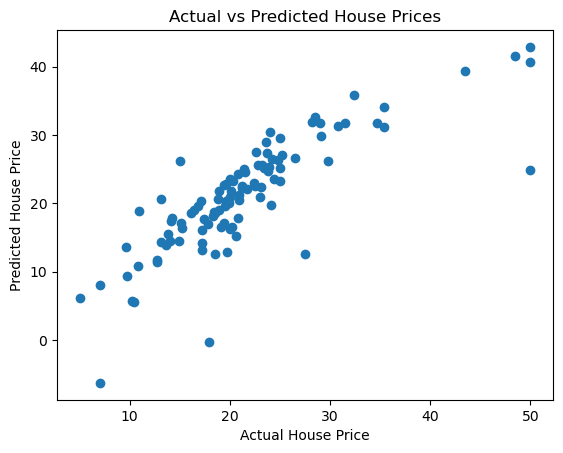

In [25]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [26]:
sample_house = X_test.iloc[0]

print("Sample house features:")
print(sample_house)

Sample house features:
Unnamed: 0    174.00000
crim            0.09178
zn              0.00000
indus           4.05000
chas            0.00000
nox             0.51000
rm              6.41600
age            84.10000
dis             2.64630
rad             5.00000
tax           296.00000
ptratio        16.60000
black         395.50000
lstat           9.04000
Name: 173, dtype: float64


In [27]:
sample_house = sample_house.values.reshape(1, -1)

predicted_price = model.predict(sample_house)

print("Predicted price for sample house:")
print(predicted_price[0])

Predicted price for sample house:
28.973353639142363


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
